In [3]:
# 머신러닝
# 지도학습 => 정답 O
    # 분류(Classification), 회귀(Regression)
# 비지도 학습 => 정답 X
    # 클러스터링, 군집
# 강화학습
# 딥러닝 - 신경망

# EDA(탐색적 데이터 분석) - 모델 - 추론
    # 데이터 전처리
        # 이상치 제거(대치), 결측치 제거(대치), 새로운 피처 생성
        # 상관지수를 통한 적절한 변수 선택
    # 적절한 모델 선택
    # 평가
    # 추론

In [4]:
# y = ax + b
# y 정답
# x 입력값
# a 기울기
# b 절편(bias) 값을 미세조정(보정)하는 의미

In [5]:
%conda install scikit-learn

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.




==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.1

Please update conda by running

    $ conda update -n base -c defaults conda




In [6]:
%conda update -n base -c defaults conda

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.




==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.1

Please update conda by running

    $ conda update -n base -c defaults conda




In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [5]:
# 데이터 준비
x = np.array([1,2,3,4,5]).reshape(-1,1) # 2차 이상으로 
y = np.array([50,60,65,70,72])
print(x.shape, y.shape)

# 모델 생성
model = LinearRegression()
# 모델 학습
model.fit(x,y)

# 학습 결과
print(f"기울기 : {model.coef_}")
print(f"절편 : {model.intercept_}")

# y = 10x + 40  # 입력의 모양을 맞춰줘야함 (여기선 2차원)

new_x = np.array([5,10,3.5,20]).reshape(-1,1)
print(f"새로운 데이터 x에 대한 모델이 예측한 값 : {model.predict(new_x)}")

(5, 1) (5,)
기울기 : [5.4]
절편 : 47.199999999999996
새로운 데이터 x에 대한 모델이 예측한 값 : [ 74.2 101.2  66.1 155.2]


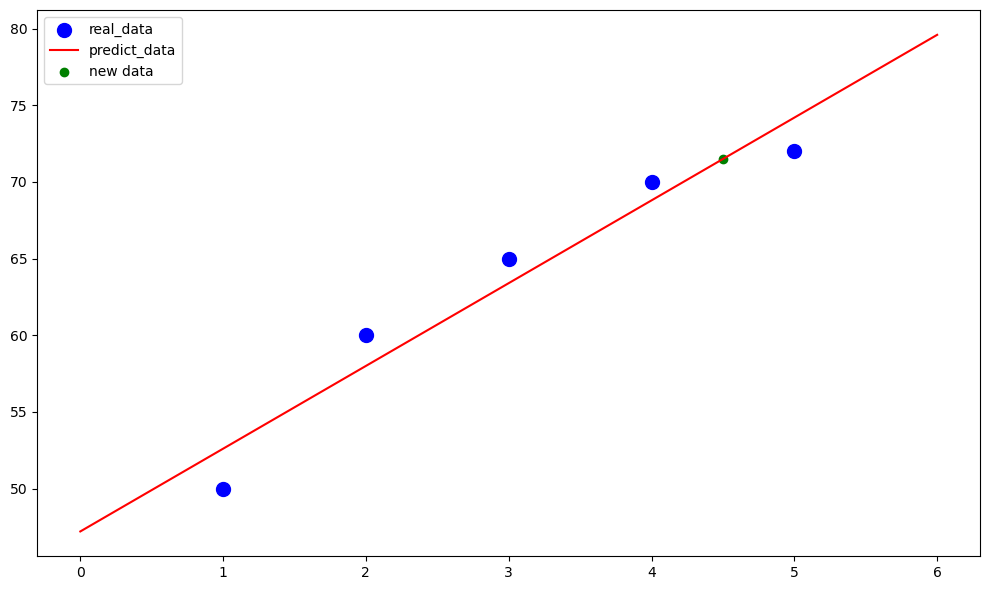

In [9]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(x,y,color = 'b', s=100, label='real_data')
#머신러닝이 예측한 예측 직선
x_line = np.linspace(0,6,100).reshape(-1,1)
y_line = model.predict(x_line)
ax.plot(x_line, y_line, color='r', label='predict_data')
# 새로운 예측값
new_x = np.array([[4.5]])
new_y = model.predict(new_x)
ax.scatter(new_x, new_y, color='g', label='new data')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


In [11]:
load_diabetes(as_frame=True).frame

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [12]:
# 정규화 : 각 원소를 평균으로 뺀 값을 표준편차로 나눔

data = np.array([10,20,30])
data.mean(), data.std()

standard_data = (data-data.mean()) / data.std()
standard_data.mean(), round(standard_data.std(), 1)


(np.float64(0.0), np.float64(1.0))

(array([ 7., 42., 68., 51., 31., 19., 12.,  7.,  3.,  4.]),
 array([-1.88154652, -1.34418508, -0.80682363, -0.26946218,  0.26789926,
         0.80526071,  1.34262215,  1.8799836 ,  2.41734504,  2.95470649,
         3.49206794]),
 <BarContainer object of 10 artists>)

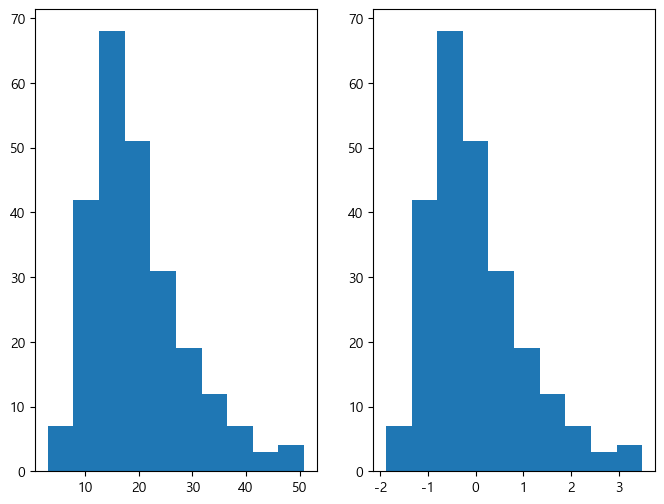

In [ ]:
tips = sns.load_dataset('tips')


data = tips['total_bill'].values
fig, axes = plt.subplots(1,2,figsize=(8,6))
axes[0].hist(data)

data_mean = data.mean()
data_std = data.std()
standard_data = (data-data_mean) / data_std

axes[1].hist(standard_data)

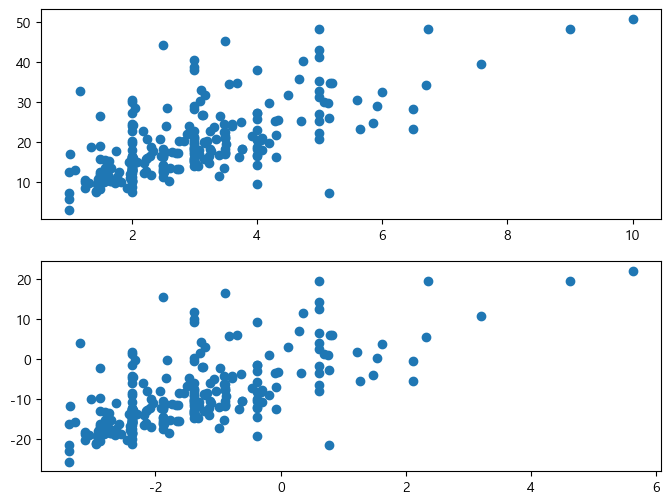

In [14]:
tips

fig, axes = plt.subplots(2,1,figsize=(8,6))
axes[0].scatter(tips['tip'],tips['total_bill'])

standard_tip = (tips['tip'] - tips['tip'].mean()) - tips['tip'].std()
standard_total_bill = (tips['total_bill'] - tips['total_bill'].mean()) - tips['total_bill'].std()
axes[1].scatter(standard_tip,standard_total_bill)

In [ ]:
df = load_diabetes(as_frame=True).frame
df.head()
x = df[['bmi']]
y = df['target']
print(x.shape, y.shape)

# y = ax + b
# 1. 모델 선택
model = LinearRegression()
# 2. 모델 학습
model.fit(x,y)
# 3. 모델 예측(추론)
predicted = model.predict(np.array([[0.061696]]))
print(predicted)


(442, 1) (442,)
[210.70984199]


c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
random_index = random.sample(range(442), 442)
x2 = x['bmi'][random_index]
y2 = y[random_index]

split_count = int(len(x['bmi'])*0.8)
x2_train = x2[:split_count].values.reshape(-1,1)
y2_train = y2[:split_count]
# y2_train.to_numpy().reshape(-1,1)
model = LinearRegression()
model.fit( x2_train, y2_train )# 모델 학습

x2_test =  x2[split_count:].values.reshape(-1,1)
y2_test =  y2[split_count:]

# 예측
predicted = model.predict( x2_test )
predicted[:5], y2_test[:5]

mean_absolute_error(y2_test, predicted), mean_squared_error(y2_test, predicted)**(1/2), r2_score(y2_test, predicted)

(47.62159942286388, 60.112923495055135, 0.3469716812704807)

In [17]:
# 데이터 (X, Y)
# 데이터를 섞에서 분할 (학습용, 테스트용)
# 적절한 모델 선택
# 학습 => 학습용 데이터
# 추론(예측, 분류) => 테스트용 데이터 
# 평가 : 테스트용 데이터의 실제 정답 vs 모델이 테스트용 데이터로 예측한 값의 오차

In [ ]:
# 1. 데이터 섞기 (train_test_split)
X = df[['age', 'bmi', 'bp', 's1', 's2', 's3']].to_numpy()
y = df['target'].to_numpy()
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(x_train, y_train)

predicted = model.predict(x_test)
mean_absolute_error(y_test, predicted), mean_squared_error(y_test, predicted)**(1/2), r2_score(y_test, predicted)

(45.12515662074305, 56.29738984132764, 0.42092438987935155)

In [19]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [20]:
y = np.array([1,2,3,4])

y_hat = np.array([1.2, 1.9, 3.2, 3.7])

# 평균
y_mean = y.mean()
#SS_tot : 데이터 자체의 변동성, 데이터의 퍼짐 정도 (오차 제곱의 합)
SS_tot = sum((y - y_mean)**2)

#SS_res : 모델 오차
SS_res = sum((y - y_hat)**2) # 모델이 틀린 총량 0.18

#R2_score (결정계수) : 1 - SSres/SStot

print(f"결정계수 : {1 - SS_res/SS_tot}")
print(f"전체변동 : {SS_tot}")
print(f"모델이 틀린 총량 : {SS_res}")
print(f"모델이 설명한 부분 : {SS_tot - SS_res}")



결정계수 : 0.964
전체변동 : 5.0
모델이 틀린 총량 : 0.17999999999999997
모델이 설명한 부분 : 4.82


In [ ]:
# 데이터, 데이터 분리(훈련데이터,평가데이터), 학습(훈련데이터) 평가(평가용데이터) --> 평가함수를 통해 성능을 지표로 표현

# 1. 데이터 로드
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
# 2개의 변수 선택
feature_cols = ['bmi','bp']
x = df[feature_cols].to_numpy()
y = df['target']

# 2. 데이터 분리
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=40)

# 3. 파이프라인 구성 (전처리(스케일링)과 선형회귀를 묶음)
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()), ('model', LinearRegression())
])
pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)
print(r2_score(y_test,y_pred))

0.31709000017431


In [22]:
# 선형회귀 LinearRegression
# 데이터 분할 train_test_split
# 모델 평가 지표(결정계수, 평균제곱오차, 평균절대값오차)
# 파이프라인

In [ ]:
# 오리지널
df = sns.load_dataset('diamonds')
df.head()
# carat depth table 학습해서 price 예측하는 모델 개발
X = df[['carat', 'depth', 'table']].to_numpy()
y = df['price']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)
predicted = model.predict(x_test)


mse = mean_squared_error(y_test, predicted)**(1/2)
mae = mean_absolute_error(y_test, predicted)
r2 = r2_score(y_test, predicted)
print(mse, mae, r2)

1527.7052003838896 994.7366650921992 0.8531855448942561


In [24]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # 규칙을 적용하고 저용한 규칙 기반으로 데이터를 변환
x_test_scaled = scaler.transform(x_test)
model = LinearRegression()
model.fit(x_train, y_train)
y_scaled_predict = model.predict(x_test_scaled)

mse = mean_squared_error(y_test, predicted)**(1/2)
mae = mean_absolute_error(y_test, predicted)
r2 = r2_score(y_test, predicted)
print(mse, mae, r2)

1527.7052003838896 994.7366650921992 0.8531855448942561


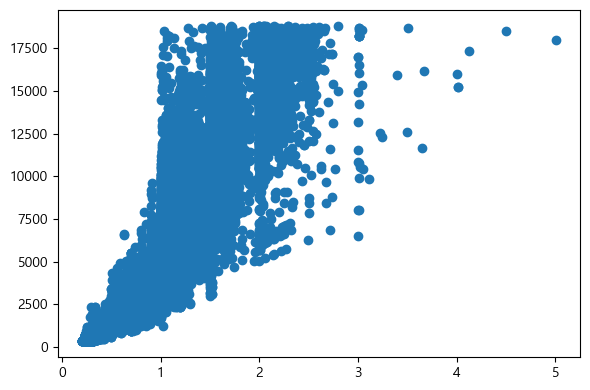

In [25]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(df['carat'], df['price'])
plt.tight_layout()
plt.show()

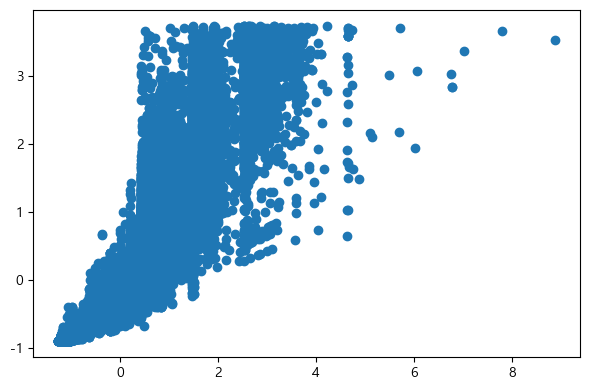

In [ ]:
# 정규화
s = StandardScaler()
s.fit_transform(df[['price']])

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(s.fit_transform(df[['carat']]),
            s.fit_transform(df[['price']]))
plt.tight_layout()
plt.show()


In [ ]:
# 파이프라인 적용
# 1. 데이터로드
# 2. 분할
# 3. 파이프라인 설계 
# 4. 파이프라인 학습
# 5. 파이프라인 예측

########### 데이터 로드 및 분할 ###########
X = df[['carat', 'depth', 'table']].to_numpy()
y = df['price']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
########### 파이프라인 설계 ###########
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
########### 파이프라인 학습  ###########
pipeline.fit(x_train, y_train)
y_predict = pipeline.predict(x_test)
########### 파이프라인 평가 ###########
print( mean_squared_error(y_test, y_predict), mean_absolute_error(y_test, y_predict), r2_score(y_test, y_predict) )

print( pipeline.score(x_test, y_test) )


2333883.1792799844 994.7366650922036 0.8531855448942559
0.8531855448942559
